# Estimating Decorrelation Length Scales

**From the TPOSE24 3-month, 3-hourly run — for AUV array sampling-error analysis of mean upwelling**

This report works through the instructions in
[`decorrelation_scales_instructions.pdf`](decorrelation_scales_instructions.pdf)
step by step.

**Model / region / depth.** `oct2012_3mo_dt300_AB3` (Δt = 300 s, 3-hourly `diag_state`,
727 records ≈ 90.9 days). Velocity **U, V, W at a single 25 m level** — the model level
*nearest* 25 m (a value at one depth, **not** a depth average) — over the equatorial 140°W
footprint, **lon 215–225°E (145–135°W), lat −5…5°N**. Every map, covariance and scale presented 
is at at 25 m. The heavy model read is done once by `compute_cache.py` and cached.

### Goal and a key distinction
We want the **spatial** decorrelation scales — how correlated two observations are as a
function of their spatial separation. Because the gliders sample *instantaneously*, the
relevant covariance is that of the **fluctuation** field, estimated by averaging over
the **temporal** dimension (all 727 slices). Two distinct things:

* **(a)** the spatial coherence scale of the single **temporal-mean** map (Step 2a) — good for intuition, not directly related to the estimate error.
* **(b)** the spatial covariance of the **anomalies** averaged over time (Step 2b) — what actually feeds the plane-fit error.

We keep zonal and meridional directions distinct because of strong equatorial anisotropy.

## Setup — imports, configuration, shared helpers

In [1]:
import os, sys, warnings
sys.path.append('..')                       # repo root, for osse_tools
import numpy as np
import xarray as xr
from scipy import signal, optimize
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import osse_tools as ot
warnings.filterwarnings('ignore')

FIGDIR = 'figures'; os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({'axes.labelsize': 13, 'axes.labelweight': 'bold',
                     'axes.titlesize': 12, 'font.size': 11,
                     'figure.dpi': 110, 'savefig.dpi': 130})

# configuration (mirrors compute_cache.py)
RUN_DIR = '/data/SO3/edavenport/tpose24/oct2012_3mo_dt300_AB3'
ITERS   = list(range(36, 26172 + 36, 36))   # 3-hourly, 727 records (Δt=300 s -> step 36)
ZLEV    = 25.0                              # analysed velocity depth (m)
CACHE   = '/data/SO3/edavenport/tpose24/cache/decorr_uvw_25m.nc'


# ---- shared estimators -------------------------------------------------------
def _fft_autocov(f2d):
    '''Spatial autocovariance of ONE 2-D field via FFT, averaged over all origin
    points at fixed lag and normalised by the actual overlap count (so the tail is
    not triangularly biased). Handles NaNs. Returns the full (2ny-1, 2nx-1) map.'''
    m = np.isfinite(f2d); f = np.where(m, f2d, 0.0); w = m.astype(float)
    num = signal.fftconvolve(f, f[::-1, ::-1], mode='full')
    cnt = signal.fftconvolve(w, w[::-1, ::-1], mode='full')
    cnt[cnt < 1] = np.nan
    return num / cnt


def normalise_and_cut(C):
    '''Normalise a full autocov map by its centre value and return the zonal C(dx,0)
    and meridional C(0,dy) cuts at non-negative lag.'''
    ny = (C.shape[0] + 1) // 2; nx = (C.shape[1] + 1) // 2
    C = C / C[ny - 1, nx - 1]
    return C, C[ny - 1, nx - 1:], C[ny - 1:, nx - 1]


def _cross(lag, C, level):
    '''First lag at which the curve C drops below `level`, linearly interpolated.'''
    C = np.asarray(C, float); b = np.where(C < level)[0]
    if not b.size:
        return np.nan
    i = b[0]
    if i == 0:
        return 0.0
    return lag[i - 1] + (level - C[i - 1]) * (lag[i] - lag[i - 1]) / (C[i] - C[i - 1])

efold      = lambda lag, C: _cross(lag, C, 1 / np.e)   # e-folding scale
first_zero = lambda lag, C: _cross(lag, C, 0.0)        # first zero crossing


def fit_exp(lag, C):
    '''Fit an exponential exp(-|d|/L) to the cut, out to the first zero crossing.'''
    fz = first_zero(lag, C)
    hi = int(np.searchsorted(lag, fz)) if np.isfinite(fz) else lag.size
    hi = max(hi, 4)
    L, _ = optimize.curve_fit(lambda d, L: np.exp(-np.abs(d) / L),
                              lag[:hi], np.asarray(C)[:hi], p0=[100.0])
    return float(L[0])


## Step 0 — Load and reduce

> ~727 temporal steps (3 months × 30 days × 8/day). Pick a depth level and handle U and V separately. 
> Expect strong spatial anisotropy — keep zonal and meridional directions distinct.

**Example pseudocode:**
```python
import xarray as xr, numpy as np
from scipy import optimize, signal
ds = xr.open_dataset("model_run.nc")             # dims: time, depth, lat, lon
u = ds["U"].sel(depth=0, method="nearest")       # pick level (or .mean("depth"))
v = ds["V"].sel(depth=0, method="nearest")
u = u.sel(lat=slice(-5, 5), lon=slice(140, 180)) # regional footprint
km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * np.cos(np.deg2rad(u["lat"]))
```

**Actual code.** TPOSE24 is MITgcm output, so we read it with the repo's
`osse_tools.load_model` (via `xmitgcm`) rather than `open_dataset`. The heavy read +
regional/vertical subset is cached by `compute_cache.py`; here we just load the cache.
U, V and W come back on a common `(time, lat, lon)` grid at 25 m (W is analysed alongside
U, V from Step 1 on, with its full supplementary treatment at the end).

In [2]:
if os.path.exists(CACHE):
    dc = xr.open_dataset(CACHE)                       # fast path: precomputed cache
else:                                                 # fallback: read the model (~5 min)
    ds = ot.load_model(RUN_DIR, ITERS)
    def _load(v, gx_gy):                              # one field at 25 m over the footprint
        gx, gy = gx_gy                                # native horizontal dims for this var
        da = ds[v].sel({ot._ZCOORD.get(v, 'Z'): -ZLEV}, method='nearest') \
                  .sel({gx: slice(215, 225), gy: slice(-5, 5)})
        return da.rename({gx: 'lon', gy: 'lat'}).transpose('time', 'lat', 'lon').load()
    u_ = _load('UVEL', ot._GRID['UVEL']); v_ = _load('VVEL', ot._GRID['VVEL'])
    w_ = _load('WVEL', ot._GRID['WVEL'])
    dc = u_.to_dataset(name='U')                      # put all three on U's (lat, lon) grid
    dc['V'] = v_.interp(lat=u_.lat, lon=u_.lon)
    dc['W'] = w_.interp(lat=u_.lat, lon=u_.lon)

u, v = dc['U'], dc['V']                     # horizontal velocity components (m/s)
w = dc['W']                                 # vertical velocity (m/s); used from Step 1 on
lat, lon = u['lat'].values, u['lon'].values

# convert the grid spacing from degrees to km so every lag below is a physical distance
# (cos-lat shrinks the zonal degree->km factor away from the equator)
KM = 111.0                                  # km per degree latitude
dlat_km = np.abs(np.diff(lat)).mean() * KM
dlon_km = np.abs(np.diff(lon)).mean() * KM * np.cos(np.deg2rad(lat.mean()))
print(f'U {u.shape}, V {v.shape}, W {w.shape} at ~{ZLEV:.0f} m; '
      f'grid spacing dx={dlon_km:.2f} km (zonal), dy={dlat_km:.2f} km (merid)')
print(f'record length {u.sizes["time"]} steps = {u.sizes["time"]*3/24:.1f} days')

U (727, 240, 240), V (727, 240, 240), W (727, 240, 240) at ~25 m; grid spacing dx=4.63 km (zonal), dy=4.62 km (merid)
record length 727 steps = 90.9 days


## Step 1 — Define the mean and the fluctuations

> Compute the temporal mean at each grid point, $\bar U(x,y)$, and the anomaly
> $U'(x,y,t)=U-\bar U$. Three months is short relative to the TIW band (~20–30 day
> periods), so the temporal mean rests on only ~3–4 realisations — this is worth flagging.

**Example pseudocode:**
```python
u_bar   = u.mean("time")   # temporal mean map  U-bar(x, y)
u_prime = u - u_bar        # anomaly  U'(x, y, t), temporally detrended
```

**Actual code.** Exactly the pseudocode: form the temporal-mean maps $\bar U,\bar V,\bar W$
(kept as `u_bar`, `v_bar`, `w_bar`) and subtract them to get the anomalies $U',V',W'$, which
every step below uses. $W$ is converted to m day$^{-1}$ (the equatorial upwelling is $O(1)$),
and is shown alongside $U,V$ here and in Step 2a; its own decorrelation analysis is the
supplementary section at the end.

In [3]:
w_day = w * 86400.0                                # W: m s^-1 -> m day^-1 (upwelling ~O(1))
u_bar = u.mean('time')                             # temporal-mean maps  bar(x, y)
v_bar = v.mean('time'); w_bar = w_day.mean('time')
u_prime = u - u_bar                                # anomalies:  prime(x, y, t) = field - mean
v_prime = v - v_bar; w_prime = w_day - w_bar       #   (zero temporal mean at every grid point)
print("anomaly std:  U' = %.3f m/s   V' = %.3f m/s   W' = %.2f m/day"
      % (float(u_prime.std()), float(v_prime.std()), float(w_prime.std())))

anomaly std:  U' = 0.174 m/s   V' = 0.204 m/s   W' = 6.48 m/day


The three temporal-mean maps over the footprint (140°W = 220°E): $\bar U,\bar V$
(m s$^{-1}$) and $\bar W$ (m day$^{-1}$) — note $\bar W$ picks out the narrow equatorial
upwelling core:

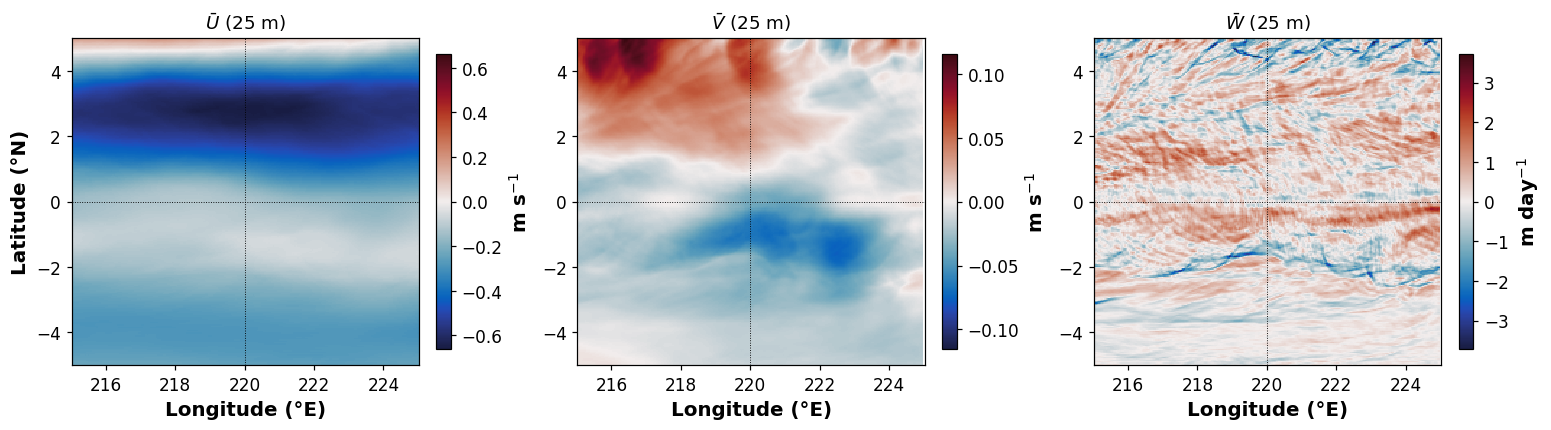

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
panels = [(u_bar, r'$\bar U$ (25 m)', 'm s$^{-1}$'), (v_bar, r'$\bar V$ (25 m)', 'm s$^{-1}$'),
          (w_bar, r'$\bar W$ (25 m)', 'm day$^{-1}$')]
for a, (fld, ttl, unit) in zip(ax, panels):
    lim = float(np.nanmax(np.abs(fld)))                     # symmetric colour range about 0
    p = a.pcolormesh(lon, lat, fld, cmap=cmo.balance, vmin=-lim, vmax=lim, shading='auto')
    a.axhline(0, color='k', lw=0.6, ls=':')                 # equator
    a.axvline(220, color='k', lw=0.6, ls=':')               # 140 W
    a.set_xlabel('Longitude (°E)'); a.set_title(ttl)
    fig.colorbar(p, ax=a, shrink=0.9, label=unit)           # units on the colorbar
ax[0].set_ylabel('Latitude (°N)')
fig.savefig(f'{FIGDIR}/fig0_mean_maps.png', bbox_inches='tight'); plt.show()

## Step 2a — Spatial autocorrelation of the mean map

> The spatial coherence scale of $\bar U$ itself: first remove the large-scale spatial
> trend (fit a plane), then form the spatial covariance vs lag
> $C(dx,dy)=\langle \bar U'(x,y)\,\bar U'(x+dx,y+dy)\rangle$, average over origins,
> normalise by $C(0,0)$, and read the 1/e scale off the zonal $C(dx,0)$ and meridional
> $C(0,dy)$ cuts. **Spatial detrending needs to be performed because
> a smooth background gradient masquerades as long-range correlation and inflates $L$**.

**Example pseudocode:**
```python
def spatial_detrend(field2d):
    y, x = np.meshgrid(field2d["lat"], field2d["lon"], indexing="ij")
    A = np.c_[np.ones(x.size), x.ravel(), y.ravel()]
    m = field2d.values.ravel(); ok = np.isfinite(m)
    coef, *_ = np.linalg.lstsq(A[ok], m[ok], rcond=None)
    return field2d - (A @ coef).reshape(field2d.shape)
ubar_p = spatial_detrend(u_bar)
f = np.nan_to_num(ubar_p.values)
C = signal.fftconvolve(f, f[::-1, ::-1], mode="full"); C /= C.max()
Cx = C[ny-1, nx-1:]; Cy = C[ny-1:, nx-1]
```

**Actual code.** Same idea for $\bar U,\bar V,\bar W$; the FFT autocov is overlap-normalised
(`_fft_autocov`) so the tail is not triangularly biased. We keep the **full 2-D map**
$C(dx,dy)$ (shown first) as well as its zonal/meridional cuts.

In [5]:
def spatial_detrend(field2d, lat, lon):
    '''Remove a best-fit plane a + b·lon + c·lat from a 2-D field.'''
    Y, X = np.meshgrid(lat, lon, indexing='ij')     # per-pixel coords for the design matrix
    A = np.c_[np.ones(X.size), X.ravel(), Y.ravel()]
    m = field2d.ravel(); ok = np.isfinite(m)        # ignore any missing values in the fit
    coef, *_ = np.linalg.lstsq(A[ok], m[ok], rcond=None)
    return field2d - (A @ coef).reshape(field2d.shape)

meanmap = {}
for name, bar in [('U', u_bar), ('V', v_bar), ('W', w_bar)]:
    bp = spatial_detrend(bar.values, lat, lon)      # remove background plane (else L inflates)
    C, Cx, Cy = normalise_and_cut(_fft_autocov(bp)) # full 2-D autocorr + zonal/merid cuts
    lx, ly = np.arange(Cx.size) * dlon_km, np.arange(Cy.size) * dlat_km   # lags -> km
    meanmap[name] = (lx, Cx, ly, Cy, C)             # stash cuts and the 2-D map
    print(f'{name}-bar map:  zonal 1/e = {efold(lx, Cx):5.0f} km   '
          f'merid 1/e = {efold(ly, Cy):5.0f} km   '
          f'(single-realisation estimate — noisy)')

U-bar map:  zonal 1/e =   nan km   merid 1/e =   107 km   (single-realisation estimate — noisy)
V-bar map:  zonal 1/e =   458 km   merid 1/e =   160 km   (single-realisation estimate — noisy)
W-bar map:  zonal 1/e =    75 km   merid 1/e =    18 km   (single-realisation estimate — noisy)


The **2-D mean-map autocorrelation** $C(dx,dy)$ for each velocity component. $\bar U$ stays coherent across the whole box zonally (the EUC is a
single coherent feature), so its map is red out to large $dx$; $\bar V,\bar W$ decorrelate faster with less anisotropy:

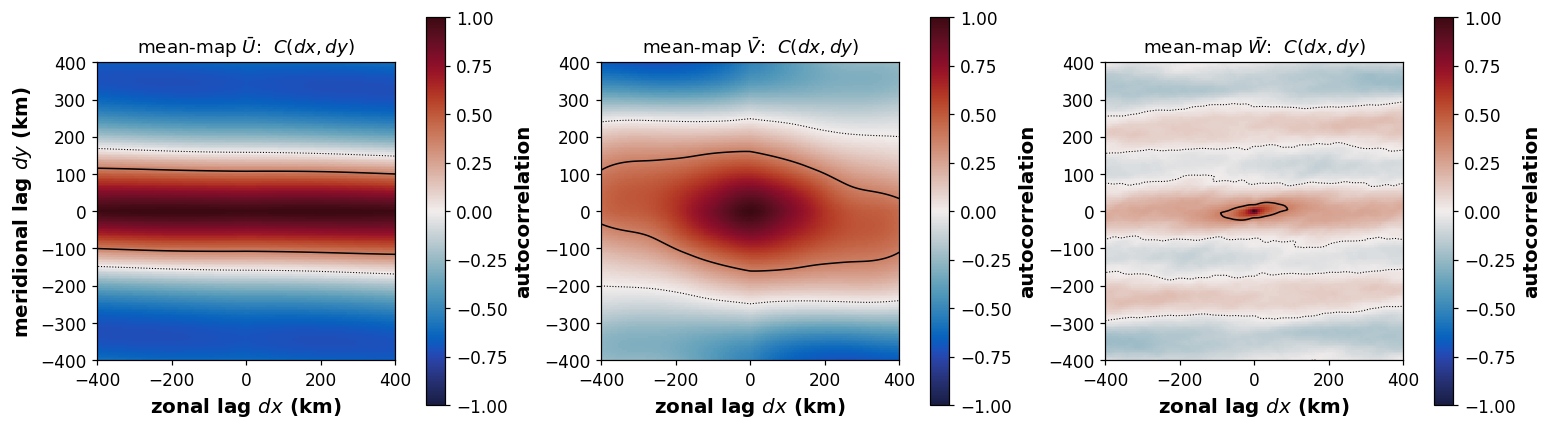

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.0), constrained_layout=True)
for a, name in zip(ax, ('U', 'V', 'W')):
    C = meanmap[name][4]                                    # the stashed 2-D map
    ny = (C.shape[0]+1)//2; nx = (C.shape[1]+1)//2          # centre index = zero lag
    LX = (np.arange(C.shape[1]) - (nx-1)) * dlon_km         # signed zonal lag (km)
    LY = (np.arange(C.shape[0]) - (ny-1)) * dlat_km         # signed meridional lag (km)
    p = a.pcolormesh(LX, LY, C, cmap=cmo.balance, vmin=-1, vmax=1, shading='auto')
    a.contour(LX, LY, C, levels=[1/np.e], colors='k', linewidths=1)          # 1/e coherence
    a.contour(LX, LY, C, levels=[0], colors='k', linewidths=0.7, linestyles=':')  # zero crossing
    a.set_xlim(-400, 400); a.set_ylim(-400, 400); a.set_aspect('equal')
    a.set_xlabel('zonal lag $dx$ (km)'); a.set_title(f'mean-map $\\bar {name}$:  $C(dx,dy)$')
    fig.colorbar(p, ax=a, shrink=0.9, label='autocorrelation')
ax[0].set_ylabel('meridional lag $dy$ (km)')
fig.savefig(f'{FIGDIR}/fig1a_step2a_meanmap_covmap.png', bbox_inches='tight'); plt.show()

And the 1-D cuts through those maps (zonal $C(dx,0)$ and meridional $C(0,dy)$):

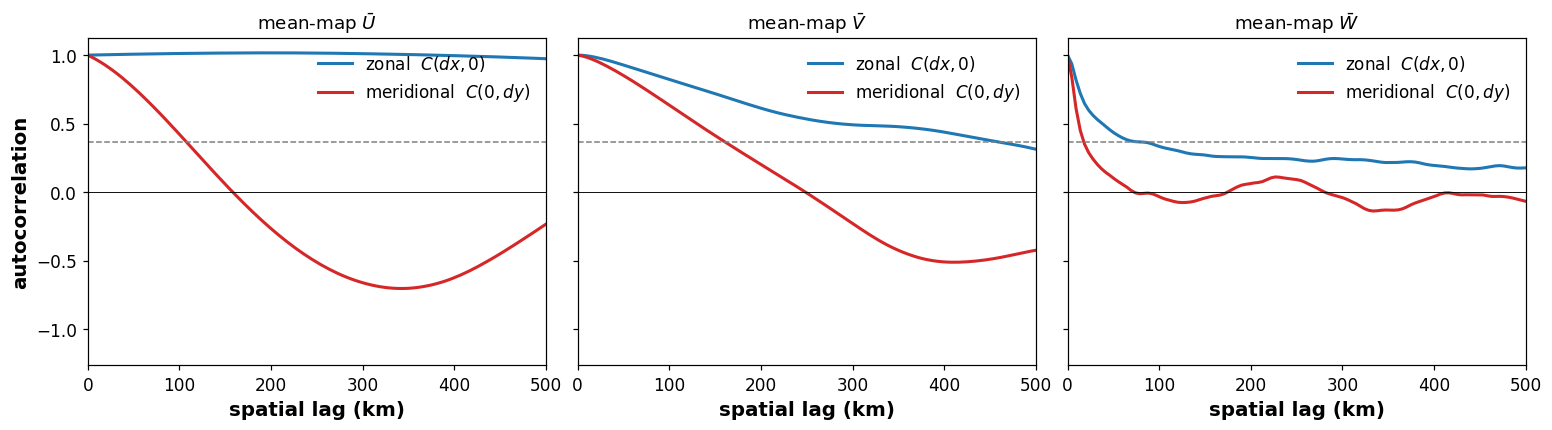

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True, sharey=True)
for a, name in zip(ax, ('U', 'V', 'W')):
    lx, Cx, ly, Cy, _ = meanmap[name]                       # the two cuts (ignore 2-D map)
    a.plot(lx, Cx, color='C0', lw=2, label='zonal  $C(dx,0)$')
    a.plot(ly, Cy, color='C3', lw=2, label='meridional  $C(0,dy)$')
    a.axhline(1/np.e, color='gray', ls='--', lw=1); a.axhline(0, color='k', lw=0.6)  # 1/e, zero
    a.set_xlim(0, 500); a.set_xlabel('spatial lag (km)'); a.set_title(f'mean-map $\\bar {name}$')
    a.legend(loc='upper right', frameon=False)
ax[0].set_ylabel('autocorrelation')
fig.savefig(f'{FIGDIR}/fig1_step2a_meanmap_cuts.png', bbox_inches='tight'); plt.show()

*Caveat (returns in Step 5):* the mean map is a **single realisation** of a
3-month average built from only ~3–4 TIW cycles, so these curves are noisy and their
long-range structure is not well constrained. The anomaly estimate below is far better
sampled.

## Step 2b — Anomaly autocovariance

> For the sampling-error problem, compute the spatial autocovariance of the **anomalies**,
> averaged over time:
> $C(dx,dy)=\langle U'(x,y,t)\,U'(x+dx,y+dy,t)\rangle$ over $x,y,t$.
> Here $U'$ is the anomaly about the temporal mean (Step 1): no *separate* spatial detrend
> is needed here, because subtracting the temporal mean already removed the stationary
> spatial structure — that time-invariant background pattern **is** the mean map
> $\bar U(x,y)$, and it is gone from every time slice once $\bar U$ is subtracted. 
> This is far better sampled (727 slices to average, not one mean map), so the fit is much more stable. 
> This map is the $C_{ij}$ that feeds the $G^{\mathsf T}C^{-1}G$ error estimate.

**Example pseudocode:**
```python
def spatial_autocov(f2d):
    f2d = np.nan_to_num(f2d)
    return signal.fftconvolve(f2d, f2d[::-1, ::-1], mode="full")
acc = np.zeros((2*ny-1, 2*nx-1))
for t in range(u_prime.sizes["time"]):
    acc += spatial_autocov(u_prime.isel(time=t).values)
C = acc / u_prime.sizes["time"]; C /= C.max()
Cx = C[C.shape[0]//2, C.shape[1]//2:]; Cy = C[C.shape[0]//2:, C.shape[1]//2]
```

**Actual code.** Accumulate the overlap-normalised per-timestep covariance and average
over time. (Averaging over origins at fixed $(dx,dy)$)

In [8]:
def anomaly_autocov(field):
    '''Spatial autocovariance of the anomalies, averaged over the temporal dim.
    Overlap-normalised numerator and count are accumulated separately across time.'''
    arr = field.values; nt, ny, nx = arr.shape
    num = np.zeros((2*ny - 1, 2*nx - 1)); cnt = np.zeros_like(num)   # accumulators
    for t in range(nt):                          # loop over every time slice
        m = np.isfinite(arr[t])                  # valid-data mask
        f = np.where(m, arr[t], 0.0)             # NaNs -> 0 for the FFT
        w = m.astype(float)                      # 1 valid / 0 masked
        num += signal.fftconvolve(f, f[::-1, ::-1], mode='full')    # raw covariance / lag
        cnt += signal.fftconvolve(w, w[::-1, ::-1], mode='full')    # valid-pair count / lag
    cnt[cnt < 1] = np.nan
    return num / cnt                             # divide by overlap -> unbiased tail

anom = {}
# U, V feed the plane-fit error; W is shown alongside for comparison
for name, fp in [('U', u_prime), ('V', v_prime), ('W', w_prime)]:
    C, Cx, Cy = normalise_and_cut(anomaly_autocov(fp))   # 2-D map + zonal/merid cuts
    anom[name] = dict(C=C, Cx=Cx, Cy=Cy,
                      lx=np.arange(Cx.size) * dlon_km, ly=np.arange(Cy.size) * dlat_km)
print('anomaly autocovariance computed for U, V and W')

anomaly autocovariance computed for U, V and W


**The anomaly fields (complement to the Step 1 / 2a mean maps).** The *time-mean* of
each anomaly is **zero at every grid point by construction**, so there is no mean anomaly map
to show. Instead we show, top row, a representative **snapshot** $U',V',W'$, and bottom row, the **RMS amplitude** over
the record (where the fluctuation energy lives). These are the fields whose spatial autocovariance Step 2b measures.

snapshot at day 22.1 of the record (peak TIW activity)


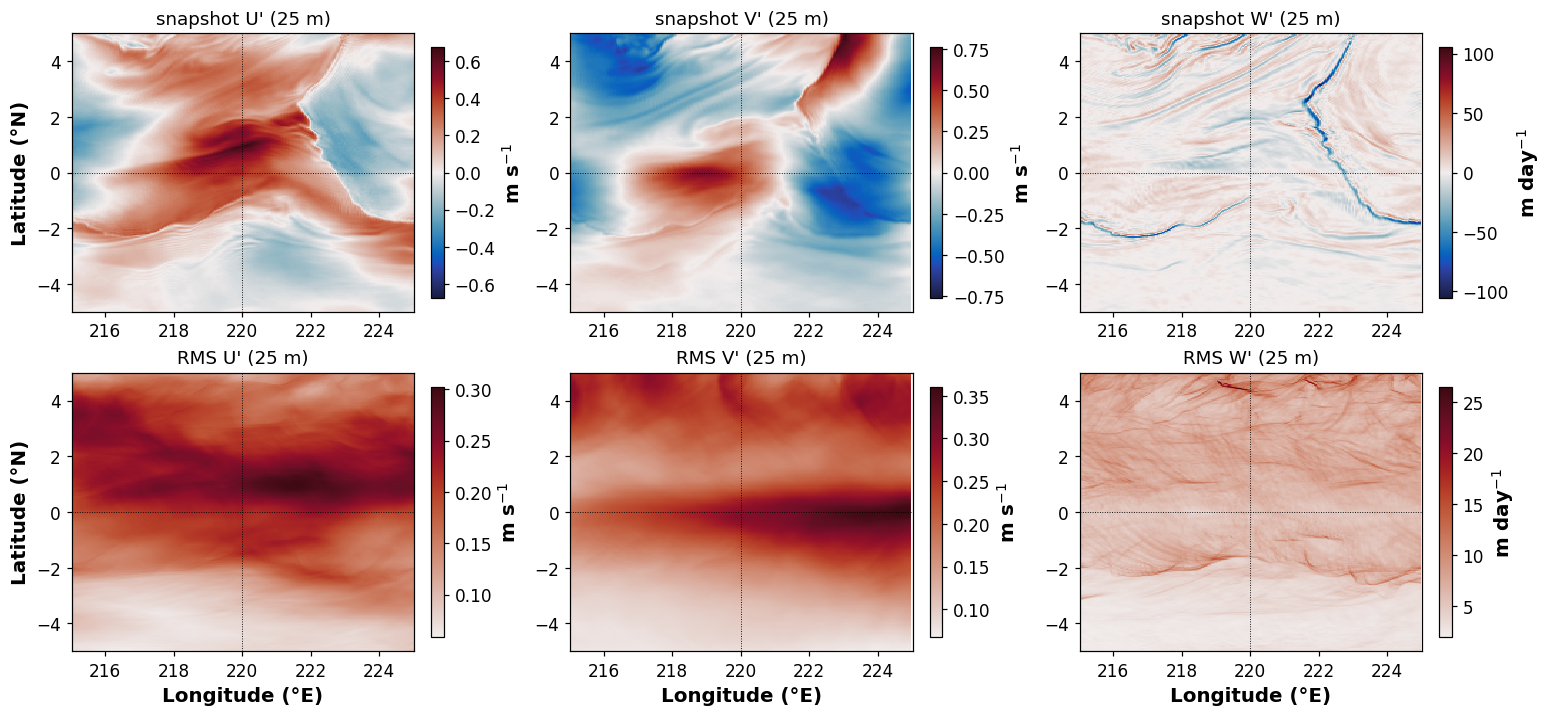

In [9]:
t0 = int((v_prime**2).mean(['lat', 'lon']).argmax())    # snapshot time = strongest domain |V'|
print(f"snapshot at day {t0*3/24:.1f} of the record (peak TIW activity)")
snap = [(u_prime.isel(time=t0), "U'", 'm s$^{-1}$'),
        (v_prime.isel(time=t0), "V'", 'm s$^{-1}$'),
        (w_prime.isel(time=t0), "W'", 'm day$^{-1}$')]
rms  = [(u_prime.std('time'), "RMS U'", 'm s$^{-1}$'),
        (v_prime.std('time'), "RMS V'", 'm s$^{-1}$'),
        (w_prime.std('time'), "RMS W'", 'm day$^{-1}$')]
fig, ax = plt.subplots(2, 3, figsize=(14, 6.4), constrained_layout=True)
for a, (fld, ttl, unit) in zip(ax[0], snap):             # top row: instantaneous anomaly (25 m)
    lim = float(np.nanmax(np.abs(fld)))                  # symmetric range about 0
    p = a.pcolormesh(lon, lat, fld, cmap=cmo.balance, vmin=-lim, vmax=lim, shading='auto')
    a.axhline(0, color='k', lw=0.6, ls=':'); a.axvline(220, color='k', lw=0.6, ls=':')
    a.set_title(f'snapshot {ttl} (25 m)'); fig.colorbar(p, ax=a, shrink=0.9, label=unit)
for a, (fld, ttl, unit) in zip(ax[1], rms):              # bottom row: RMS over time (25 m, >= 0)
    p = a.pcolormesh(lon, lat, fld, cmap=cmo.amp, shading='auto')
    a.axhline(0, color='k', lw=0.6, ls=':'); a.axvline(220, color='k', lw=0.6, ls=':')
    a.set_xlabel('Longitude (°E)'); a.set_title(f'{ttl} (25 m)')
    fig.colorbar(p, ax=a, shrink=0.9, label=unit)
for a in ax[:, 0]:
    a.set_ylabel('Latitude (°N)')
fig.savefig(f'{FIGDIR}/fig1c_step2b_anomaly_fields.png', bbox_inches='tight'); plt.show()

The **2-D anomaly autocovariance** $C(dx,dy)$ for $U',V',W'$ — the object that goes into
the covariance matrix (for $U,V$). $W'$ nearly collapses to the origin; its scale is ~10× shorter (a zoomed
$W$ view is in the supplementary section):

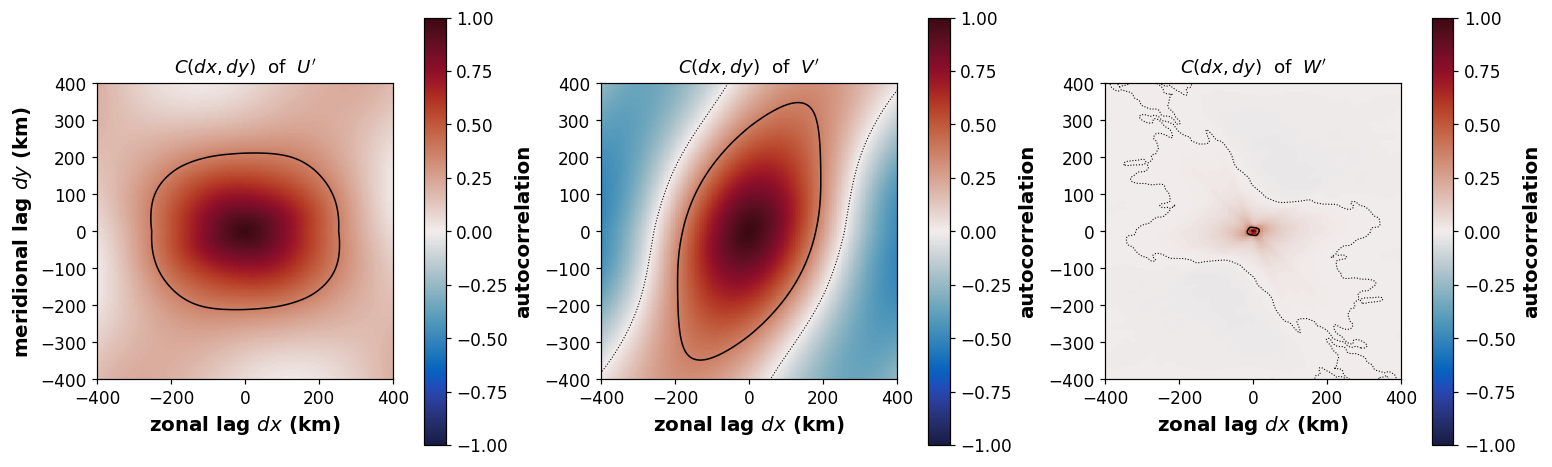

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)
for a, name in zip(ax, ('U', 'V', 'W')):
    C = anom[name]['C']; ny = (C.shape[0]+1)//2; nx = (C.shape[1]+1)//2   # centre = zero lag
    LX = (np.arange(C.shape[1]) - (nx-1)) * dlon_km         # signed zonal lag (km)
    LY = (np.arange(C.shape[0]) - (ny-1)) * dlat_km         # signed meridional lag (km)
    p = a.pcolormesh(LX, LY, C, cmap=cmo.balance, vmin=-1, vmax=1, shading='auto')
    a.contour(LX, LY, C, levels=[1/np.e], colors='k', linewidths=1)          # 1/e coherence
    a.contour(LX, LY, C, levels=[0], colors='k', linewidths=0.7, linestyles=':')  # zero
    a.set_xlim(-400, 400); a.set_ylim(-400, 400); a.set_aspect('equal')
    a.set_xlabel('zonal lag $dx$ (km)'); a.set_title(f"$C(dx,dy)$  of  ${name}'$")
    fig.colorbar(p, ax=a, shrink=0.9, label='autocorrelation')
ax[0].set_ylabel('meridional lag $dy$ (km)')
fig.savefig(f'{FIGDIR}/fig2_step2b_covmap.png', bbox_inches='tight'); plt.show()

## Steps 3 & 4 — Fit a functional form, account for oscillatory structure

> **Step 3.** Don't just read a single 1/e point — it is noisy and the tail shape controls
> $C^{-1}$. Fit the empirical $C(dx,0)$ and $C(0,dy)$ to a model in spatial lag
> (exponential $e^{-|d|/L}$, Gaussian, or Matérn), with separate $L_x$, $L_y$
> (anisotropy). Fitting also gives a positive-definite covariance later.
>
> **Step 4.** In the equatorial band, TIWs produce real *negative* spatial correlations
> at certain lags (the field reverses across a wave), so $C$ undershoots and oscillates
> rather than decaying monotonically. A pure exponential is then the wrong model: report
> the **e-folding scale** (coherence) and the **first-zero-crossing scale** (half-wavelength) separately. 
> Samples a half-wavelength apart are anti-correlated, not independent.

**Example pseudocode:**
```python
def model(lag_km, L):            # exponential; swap for Gaussian/Matern
    return np.exp(-np.abs(lag_km) / L)
lag_x_km = np.arange(Cx.size) * dlon_km
lag_y_km = np.arange(Cy.size) * dlat_km
Lx, _ = optimize.curve_fit(model, lag_x_km, Cx, p0=[100.0])
Ly, _ = optimize.curve_fit(model, lag_y_km, Cy, p0=[50.0])  # expect Lx >> Ly
```

**Actual code.** The cuts fitted here are exactly the zonal $C(dx,0)$ and meridional
$C(0,dy)$ **slices through the Step 2b covariance maps** — the same `anom[name]['Cx']`,
`['Cy']` arrays. Fit the exponential out to the first zero crossing, and separately record
the empirical 1/e and zero-crossing scales (Step 4). The fitted-scale **table** below stays
$U,V$ (the error-relevant components); the **figure** adds a $W'$ panel for comparison.

In [11]:
rows = []
for name in ('U', 'V'):                                # table: error-relevant components only
    d = anom[name]
    for axis, lag, C in [('zonal', d['lx'], d['Cx']), ('merid', d['ly'], d['Cy'])]:
        rows.append(dict(comp=name, axis=axis,        # three scale measures per cut:
                         L_fit=fit_exp(lag, C),        #   exponential fit to the coherent core
                         L_efold=efold(lag, C),        #   empirical 1/e crossing
                         zero=first_zero(lag, C)))     # first zero (TIW half-wavelength)

print(f"{'comp':4} {'axis':6} {'L_fit(km)':>10} {'1/e(km)':>9} {'zero-cross(km)':>15}")
for r in rows:
    z = f"{r['zero']:.0f}" if np.isfinite(r['zero']) else 'n/a'
    print(f"{r['comp']:4} {r['axis']:6} {r['L_fit']:10.0f} {r['L_efold']:9.0f} {z:>15}")

Lx = next(r for r in rows if r['comp'] == 'U' and r['axis'] == 'zonal')['L_fit']
Ly = next(r for r in rows if r['comp'] == 'U' and r['axis'] == 'merid')['L_fit']
print(f"\nanisotropy (U):  Lx/Ly = {Lx/Ly:.2f}  (expect Lx >~ Ly in the equatorial band)")

comp axis    L_fit(km)   1/e(km)  zero-cross(km)
U    zonal         246       253             452
U    merid         200       211             514
V    zonal         194       180             257
V    merid         276       282             502

anisotropy (U):  Lx/Ly = 1.23  (expect Lx >~ Ly in the equatorial band)


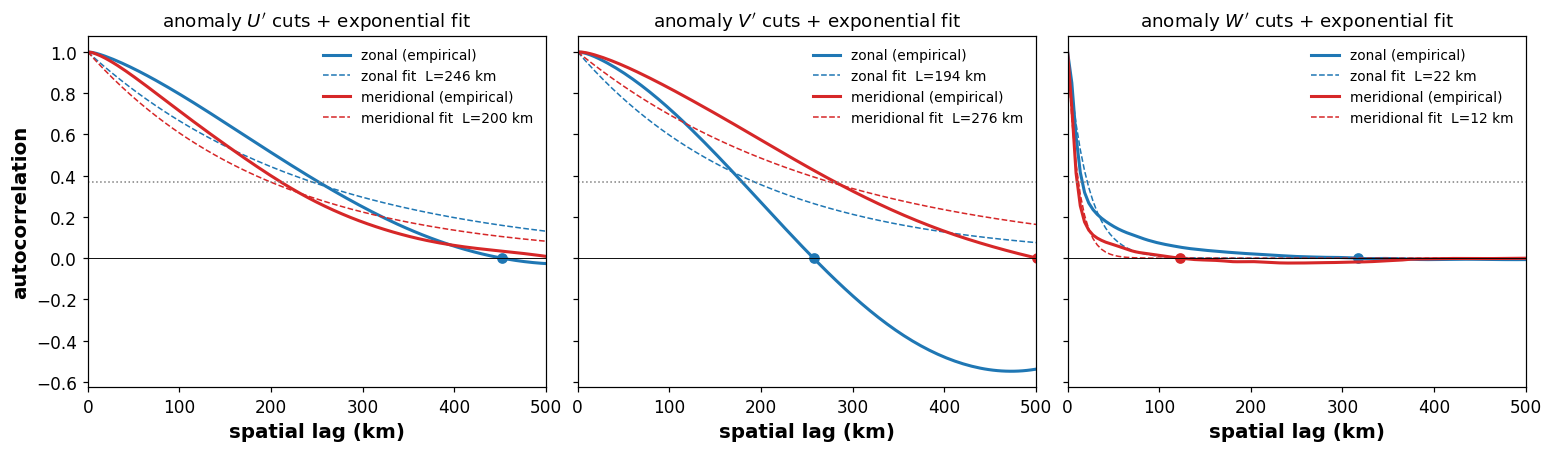

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.0), constrained_layout=True, sharey=True)
for a, name in zip(ax, ('U', 'V', 'W')):
    d = anom[name]                                          # cuts = slices of the Step 2b map
    for lag, C, col, lab in [(d['lx'], d['Cx'], 'C0', 'zonal'),
                             (d['ly'], d['Cy'], 'C3', 'meridional')]:
        a.plot(lag, C, col, lw=2, label=f'{lab} (empirical)')
        L = fit_exp(lag, C)                                 # exp fit to the coherent core
        a.plot(lag, np.exp(-lag / L), col, lw=1, ls='--',
               label=f'{lab} fit  L={L:.0f} km')
        fz = first_zero(lag, C)
        if np.isfinite(fz):
            a.plot(fz, 0, col, marker='o', ms=6)            # first zero crossing
    a.axhline(1/np.e, color='gray', ls=':', lw=1); a.axhline(0, color='k', lw=0.6)
    a.set_xlim(0, 500); a.set_xlabel('spatial lag (km)')
    a.set_title(f"anomaly ${name}'$ cuts + exponential fit")
    a.legend(loc='upper right', frameon=False, fontsize=9)
ax[0].set_ylabel('autocorrelation')
fig.savefig(f'{FIGDIR}/fig3_step34_cuts_fits.png', bbox_inches='tight'); plt.show()

Circles mark the **first zero crossing**. The exponential isn't very good for U and V and should probably be replaced with a different function.
The zero-crossing scale is the physically meaningful "independence" distance and is the one to consider when placing gliders.

## Step 5 — Error bars on L

> The effective number of independent maps is set by the **temporal** decorrelation time,
> not the count of samples in time. Estimate it from the temporal-lag autocorrelation of $U'(t)$;
> Divide the record length by that temporal scale for the effective DOF, and use it to
> put a confidence interval on the fitted $L_x$, $L_y$. The short record may genuinely undersample the low-frequency mean.
> TODO: Need to come back to this to do CI and understand it better

**Example pseudocode:**
```python
ts = u_prime.isel(lat=j0, lon=i0).values
ac = signal.correlate(ts, ts, mode="full"); ac = ac[ac.size//2:] / ac[ac.size//2]
tau_steps = np.argmax(ac < 1/np.e); tau_days = tau_steps * (3/24)
N_eff = 90.0 / tau_days             # scale L uncertainty like 1/sqrt(N_eff)
```

**Actual code.** Rather than one point, average the temporal autocovariance over every
grid point in the footprint (vectorised FFT over the time axis) for a robust τ.

In [13]:
def mean_temporal_ac(field):
    '''Region-averaged temporal autocovariance (FFT along time, averaged over pixels).'''
    A = field.values.reshape(field.sizes['time'], -1).astype(float)   # (time, pixels)
    A = np.nan_to_num(A - np.nanmean(A, 0)); nt = A.shape[0]          # demean each pixel in time
    F = np.fft.rfft(A, n=2*nt, axis=0)                               # zero-padded FFT along time
    ac = np.fft.irfft(F * np.conj(F), n=2*nt, axis=0)[:nt].sum(1)    # power -> autocov, /pixels
    return ac / ac[0]                                                # normalise to 1 at zero lag

lag_days = np.arange(u.sizes['time']) * (3/24)     # temporal lag axis (3-hourly cadence)
rec_days = u.sizes['time'] * (3/24)                # total record length in days
tau, Neff = {}, {}
for name, fp in [('U', u_prime), ('V', v_prime)]:
    ac = mean_temporal_ac(fp)
    tau[name] = efold(lag_days, ac)                # 1/e temporal decorrelation scale (days)
    Neff[name] = rec_days / tau[name]              # effective # of independent realisations
    print(f"{name}':  tau = {tau[name]:.1f} days   "
          f"N_eff = {Neff[name]:.1f} independent realisations in {rec_days:.0f} days")

# confidence interval on each fitted L: standard error scales like L / sqrt(N_eff)
print()
for r in rows:
    n = Neff[r['comp']]; L = r['L_fit']; se = L / np.sqrt(n)
    print(f"{r['comp']} {r['axis']:6}  L = {L:5.0f} +/- {se:4.0f} km  "
          f"(+/- {100*se/L:.0f}%),  N_eff={n:.1f}")

U':  tau = 5.3 days   N_eff = 17.1 independent realisations in 91 days


V':  tau = 3.9 days   N_eff = 23.3 independent realisations in 91 days

U zonal   L =   246 +/-   60 km  (+/- 24%),  N_eff=17.1
U merid   L =   200 +/-   48 km  (+/- 24%),  N_eff=17.1
V zonal   L =   194 +/-   40 km  (+/- 21%),  N_eff=23.3
V merid   L =   276 +/-   57 km  (+/- 21%),  N_eff=23.3


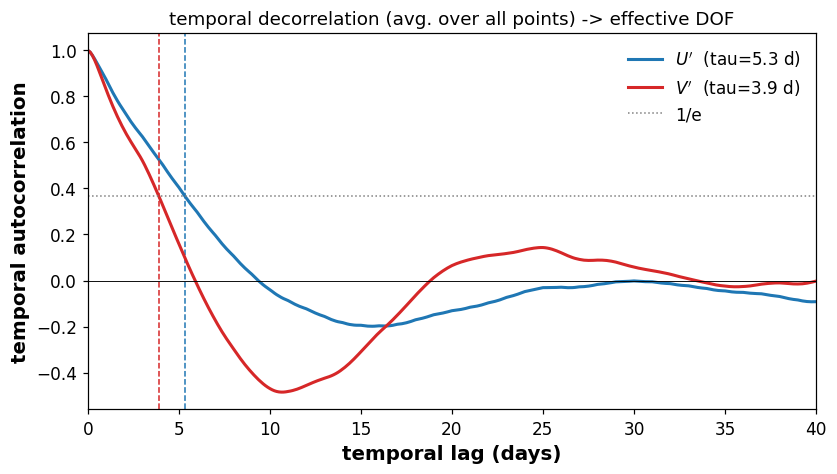

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
for name, col in [('U', 'C0'), ('V', 'C3')]:
    ac = mean_temporal_ac(u_prime if name == 'U' else v_prime)
    ax.plot(lag_days, ac, col, lw=2, label=f"${name}'$  (tau={tau[name]:.1f} d)")
    ax.axvline(tau[name], color=col, ls='--', lw=1)
ax.axhline(1/np.e, color='gray', ls=':', lw=1, label='1/e')
ax.axhline(0, color='k', lw=0.6)
ax.set_xlim(0, 40); ax.set_xlabel('temporal lag (days)')
ax.set_ylabel('temporal autocorrelation')
ax.set_title('temporal decorrelation (avg. over all points) -> effective DOF')
ax.legend(loc='upper right', frameon=False)
fig.savefig(f'{FIGDIR}/fig4_step5_temporal.png', bbox_inches='tight'); plt.show()

## Practical notes — the equator, and grid resolution

> * **Handle the equator explicitly:** dynamics change character across it (Coriolis → 0),
>   so a window straddling the equator mixes regimes and yields a meaningless blended $L$.
>   Consider computing each side separately.
> * **Confirm how many grid points fall inside one decorrelation length;** if few, the
>   estimate becomes grid-resolution-limited.

**Actual code.** Redo the anomaly meridional scale separately for a northern band
(0.5–5°N) and a southern band (−5…−0.5°N), and count grid points per scale.

In [15]:
def band_scales(field, lat0, lat1):
    '''Anomaly spatial cuts over a single latitude band (full zonal extent).'''
    fp = field.sel(lat=slice(lat0, lat1))               # restrict to the band before averaging
    _, Cx, Cy = normalise_and_cut(anomaly_autocov(fp))
    lx = np.arange(Cx.size) * dlon_km; ly = np.arange(Cy.size) * dlat_km
    return lx, Cx, ly, Cy

bands = {'south (−5…−0.5°N)': (-5, -0.5), 'north (0.5…5°N)': (0.5, 5)}
band_cuts = {}
print(f"{'band':20} {'Lx_fit':>8} {'Ly_fit':>8} {'Ly 1/e':>8} {'Ly zero':>9}")
for lab, (a0, a1) in bands.items():
    lx, Cx, ly, Cy = band_scales(u_prime, a0, a1); band_cuts[lab] = (ly, Cy)
    z = first_zero(ly, Cy); zs = f'{z:.0f}' if np.isfinite(z) else 'n/a'
    print(f"{lab:20} {fit_exp(lx,Cx):8.0f} {fit_exp(ly,Cy):8.0f} "
          f"{efold(ly,Cy):8.0f} {zs:>9}")

print(f"\ngrid points inside one scale (U anomaly, full region):")
print(f"  zonal  Lx={Lx:.0f} km / dx={dlon_km:.2f} km = {Lx/dlon_km:.0f} points")
print(f"  merid  Ly={Ly:.0f} km / dy={dlat_km:.2f} km = {Ly/dlat_km:.0f} points  "
      f"(well resolved — not grid-limited)")

band                   Lx_fit   Ly_fit   Ly 1/e   Ly zero


south (−5…−0.5°N)         493      134      139       288


north (0.5…5°N)           226      198      204       352

grid points inside one scale (U anomaly, full region):
  zonal  Lx=246 km / dx=4.63 km = 53 points
  merid  Ly=200 km / dy=4.62 km = 43 points  (well resolved — not grid-limited)


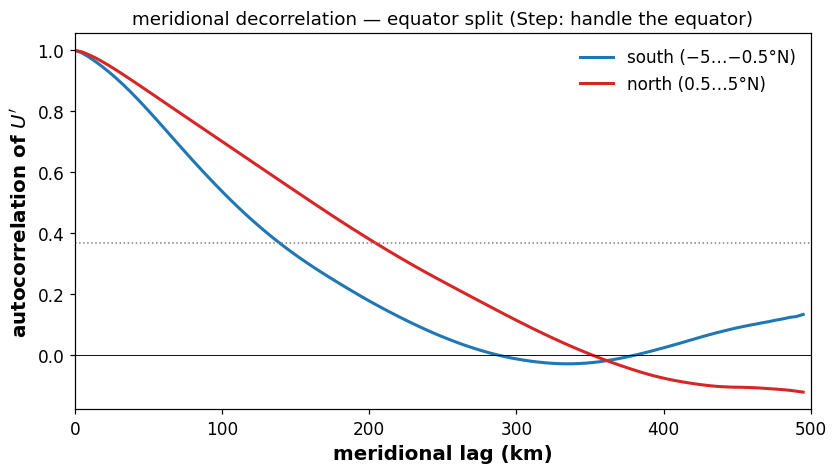

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
for (lab, (ly, Cy)), col in zip(band_cuts.items(), ['C0', 'C3']):
    ax.plot(ly, Cy, col, lw=2, label=lab)
ax.axhline(1/np.e, color='gray', ls=':', lw=1); ax.axhline(0, color='k', lw=0.6)
ax.set_xlim(0, 500); ax.set_xlabel('meridional lag (km)')
ax.set_ylabel("autocorrelation of $U'$")
ax.set_title('meridional decorrelation — equator split (Step: handle the equator)')
ax.legend(loc='upper right', frameon=False)
fig.savefig(f'{FIGDIR}/fig5_equator_split.png', bbox_inches='tight'); plt.show()

## Supplementary — vertical velocity $W$

$W$ does **not** enter the plane-fit sampling error: that covariance is built from the
*sampled horizontal* velocity $(U,V)$, from which the array reconstructs the divergence
$\partial_x U+\partial_y V$ and hence $W$ through continuity. But $W$ is the quantity we
ultimately want (the equatorial upwelling), so its own mean structure and decorrelation
scales are worth recording — how wide the upwelling core is, how far apart two $W$ samples
must be to be independent, and how long a $W$ feature persists. Same footprint, depth
(25 m), m day $^{-1}$ units and estimators as in Steps 1–2a; here we add the anomaly
decorrelation map/scales, the temporal $\tau_W$, and the equator split.

In [17]:
# w_day, w_bar, w_prime were defined in Step 1 (W in m/day); recap its mean structure:
print("W-bar: domain mean = %+.2f m/day (range %+.2f .. %+.2f);  W' std = %.2f m/day"
      % (float(w_bar.mean()), float(w_bar.min()), float(w_bar.max()), float(w_prime.std())))

W-bar: domain mean = +0.11 m/day (range -3.71 .. +2.65);  W' std = 6.48 m/day


**Mean map (repeated from Step 1 with its meridional profile).** The time-mean vertical
velocity $\bar W$ and its zonal-mean profile — the equatorial upwelling core straddling the
equator:

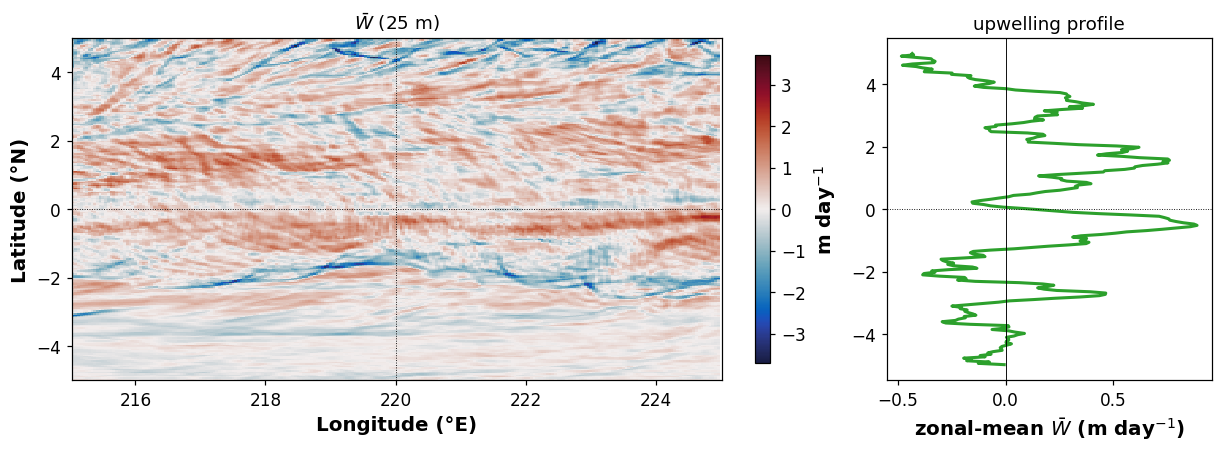

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0), constrained_layout=True,
                       gridspec_kw={'width_ratios': [2, 1]})
lim = float(np.nanmax(np.abs(w_bar)))
p = ax[0].pcolormesh(lon, lat, w_bar, cmap=cmo.balance, vmin=-lim, vmax=lim, shading='auto')
ax[0].axhline(0, color='k', lw=0.6, ls=':'); ax[0].axvline(220, color='k', lw=0.6, ls=':')
ax[0].set_xlabel('Longitude (°E)'); ax[0].set_ylabel('Latitude (°N)')
ax[0].set_title(r'$\bar W$ (25 m)'); fig.colorbar(p, ax=ax[0], shrink=0.9, label=r'm day$^{-1}$')
ax[1].plot(w_bar.mean('lon'), lat, 'C2', lw=2)
ax[1].axvline(0, color='k', lw=0.6); ax[1].axhline(0, color='k', lw=0.6, ls=':')
ax[1].set_xlabel(r'zonal-mean $\bar W$ (m day$^{-1}$)'); ax[1].set_title('upwelling profile')
fig.savefig(f'{FIGDIR}/fig6_w_meanmap.png', bbox_inches='tight'); plt.show()

**Decorrelation map and scales (zoomed).** The same $W'$ autocovariance shown in the
Step 2b/3–4 panels, but zoomed to $W$'s own scale so its structure is visible: the 2-D
$C(dx,dy)$ with its zonal/meridional cuts and exponential fits. $W$ decorrelates over much
shorter distances than $U,V$. These scales are so short (only a few grid cells) that $W$ sits near the model's horizontal resolution;
the grid-points-per-scale printed below flags this, so treat the $W$ lengths as marginally resolved.

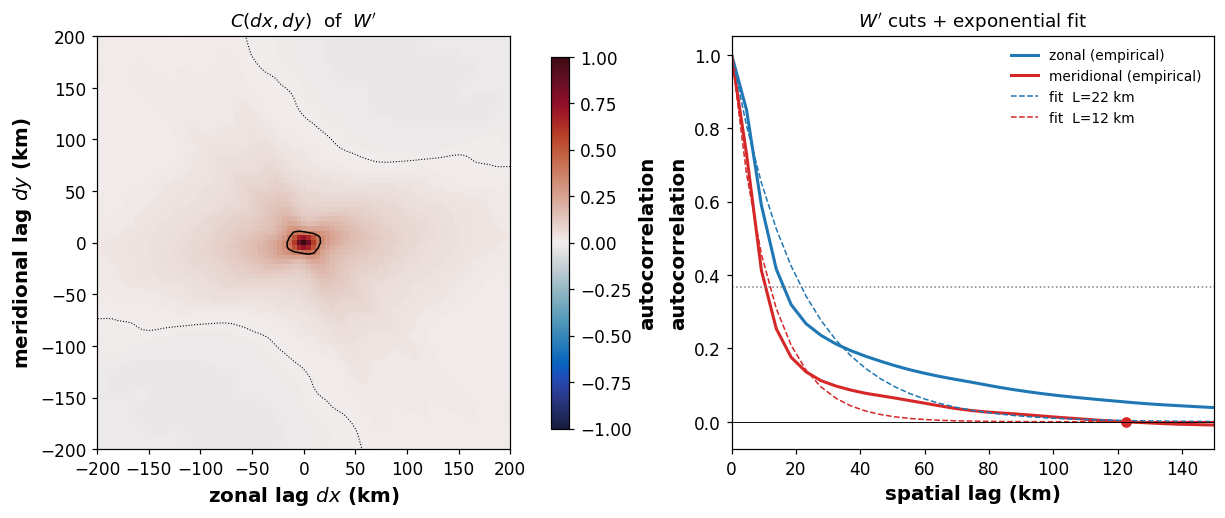

In [19]:
dW = anom['W']                                              # reuse the Step 2b W' autocov
Cw, Cwx, Cwy = dW['C'], dW['Cx'], dW['Cy']
lwx, lwy = dW['lx'], dW['ly']                               # lags in km

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
ny = (Cw.shape[0] + 1)//2; nx = (Cw.shape[1] + 1)//2         # centre index = zero lag
LX = (np.arange(Cw.shape[1]) - (nx - 1)) * dlon_km
LY = (np.arange(Cw.shape[0]) - (ny - 1)) * dlat_km
p = ax[0].pcolormesh(LX, LY, Cw, cmap=cmo.balance, vmin=-1, vmax=1, shading='auto')
ax[0].contour(LX, LY, Cw, levels=[1/np.e], colors='k', linewidths=1)
ax[0].contour(LX, LY, Cw, levels=[0], colors='k', linewidths=0.7, linestyles=':')
ax[0].set_xlim(-200, 200); ax[0].set_ylim(-200, 200); ax[0].set_aspect('equal')
ax[0].set_xlabel('zonal lag $dx$ (km)'); ax[0].set_ylabel('meridional lag $dy$ (km)')
ax[0].set_title("$C(dx,dy)$  of  $W'$")
fig.colorbar(p, ax=ax[0], shrink=0.9, label='autocorrelation')
ax[1].plot(lwx, Cwx, 'C0', lw=2, label='zonal (empirical)')
ax[1].plot(lwy, Cwy, 'C3', lw=2, label='meridional (empirical)')
for lag, C, col in [(lwx, Cwx, 'C0'), (lwy, Cwy, 'C3')]:
    L = fit_exp(lag, C)
    ax[1].plot(lag, np.exp(-lag / L), col, lw=1, ls='--', label=f'fit  L={L:.0f} km')
    fz = first_zero(lag, C)
    if np.isfinite(fz):
        ax[1].plot(fz, 0, col, marker='o', ms=6)
ax[1].axhline(1/np.e, color='gray', ls=':', lw=1); ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_xlim(0, 150); ax[1].set_xlabel('spatial lag (km)')
ax[1].set_ylabel('autocorrelation'); ax[1].set_title("$W'$ cuts + exponential fit")
ax[1].legend(loc='upper right', frameon=False, fontsize=9)
fig.savefig(f'{FIGDIR}/fig7_w_covmap.png', bbox_inches='tight'); plt.show()

In [20]:
for axis, lag, C, dg in [('zonal', lwx, Cwx, dlon_km), ('merid', lwy, Cwy, dlat_km)]:
    Lf = fit_exp(lag, C); z = first_zero(lag, C); zs = f'{z:.0f}' if np.isfinite(z) else 'n/a'
    print(f"W {axis:6}  L_fit={Lf:5.0f} km   1/e={efold(lag,C):5.0f} km   "
          f"zero-cross={zs:>5} km   ({Lf/dg:.0f} grid points inside L_fit)")
print("  -> only a few grid points per scale: W is near the horizontal\n"
      "     resolution (dx~4.6 km), so these lengths are marginally resolved.")

W zonal   L_fit=   22 km   1/e=   16 km   zero-cross=  317 km   (5 grid points inside L_fit)
W merid   L_fit=   12 km   1/e=   11 km   zero-cross=  123 km   (3 grid points inside L_fit)
  -> only a few grid points per scale: W is near the horizontal
     resolution (dx~4.6 km), so these lengths are marginally resolved.


**Temporal decorrelation.** Temporal autocorrelation of $W'$ averaged over all points →
decorrelation time $\tau_W$ and effective DOF (the same construction as Step 5 for $U,V$):

W':  tau = 0.4 days (3.1 output steps)   N_eff = 235.1 in 91 days
  -> tau_W is only a few 3-hourly steps: W is nearly decorrelated
     between snapshots (temporal scale marginally resolved too).


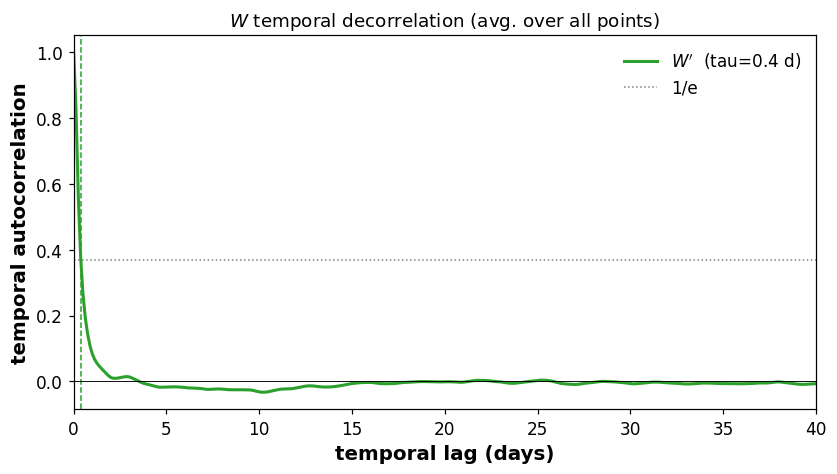

In [21]:
acw = mean_temporal_ac(w_prime); tau_w = efold(lag_days, acw); Neff_w = rec_days / tau_w
print(f"W':  tau = {tau_w:.1f} days ({tau_w/(3/24):.1f} output steps)   "
      f"N_eff = {Neff_w:.1f} in {rec_days:.0f} days")
print("  -> tau_W is only a few 3-hourly steps: W is nearly decorrelated\n"
      "     between snapshots (temporal scale marginally resolved too).")

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
ax.plot(lag_days, acw, 'C2', lw=2, label=f"$W'$  (tau={tau_w:.1f} d)")
ax.axvline(tau_w, color='C2', ls='--', lw=1)
ax.axhline(1/np.e, color='gray', ls=':', lw=1, label='1/e'); ax.axhline(0, color='k', lw=0.6)
ax.set_xlim(0, 40); ax.set_xlabel('temporal lag (days)')
ax.set_ylabel('temporal autocorrelation')
ax.set_title('$W$ temporal decorrelation (avg. over all points)')
ax.legend(loc='upper right', frameon=False)
fig.savefig(f'{FIGDIR}/fig8_w_temporal.png', bbox_inches='tight'); plt.show()

**Equator split.** As for $U,V$, the meridional $W'$ decorrelation computed
separately north and south of the equator (regimes differ where Coriolis $\to 0$):

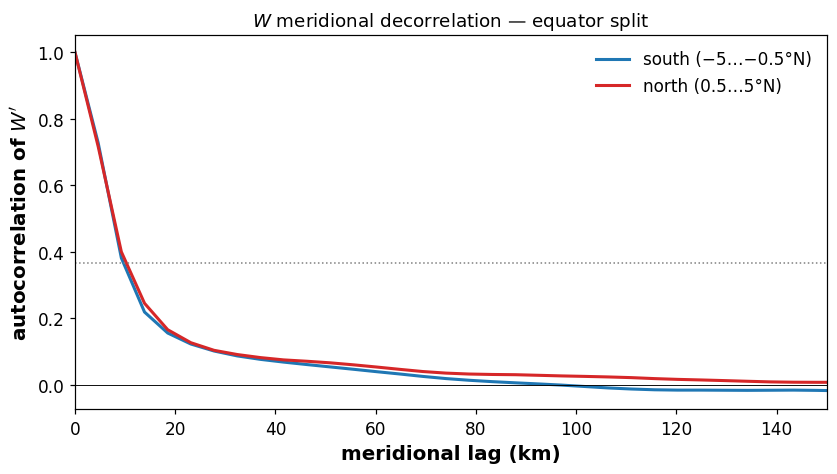

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
for (lab, (a0, a1)), col in zip(bands.items(), ['C0', 'C3']):
    _, _, ly, Cy = band_scales(w_prime, a0, a1)
    ax.plot(ly, Cy, col, lw=2, label=lab)
ax.axhline(1/np.e, color='gray', ls=':', lw=1); ax.axhline(0, color='k', lw=0.6)
ax.set_xlim(0, 150); ax.set_xlabel('meridional lag (km)')
ax.set_ylabel("autocorrelation of $W'$")
ax.set_title('$W$ meridional decorrelation — equator split')
ax.legend(loc='upper right', frameon=False)
fig.savefig(f'{FIGDIR}/fig9_w_equator_split.png', bbox_inches='tight'); plt.show()

### Decorrelation vs latitude — $U,V,W$ at 0°N vs 2°N (narrow windows)

The Step 2b/3–4 maps average over the whole box (lat −5…5°N) — a blend of latitudes, not a
value "at 0°N." Here we recompute over two **local $\pm1°$ windows** at 140°W (one at 0°N, one
at 2°N) to see how the scales change with latitude, and to **contrast the narrow window with
the wide $-5…5°$ window used earlier**. A key caveat falls straight out: a $\pm1°$ window is
only **~222 km tall**, which is *smaller* than $U,V$'s meridional scale (~200–280 km). So the
narrow window can localise the **zonal** scale of every field, but it **cannot resolve the
meridional** scale of $U,V$ — only $W$ (~15 km) fits inside it.

In [23]:
def field_scales(prime, lat_c, half=1.0):
    '''Anomaly autocov (2-D + cuts) and temporal tau over a +/-half-deg latitude
    window centred on lat_c (full zonal extent), off the cached anomalies.'''
    fp = prime.sel(lat=slice(lat_c - half, lat_c + half))
    C, Cx, Cy = normalise_and_cut(anomaly_autocov(fp))
    lx = np.arange(Cx.size) * dlon_km; ly = np.arange(Cy.size) * dlat_km
    ac = mean_temporal_ac(fp); tau = efold(lag_days, ac)
    return dict(C=C, lx=lx, Cx=Cx, ly=ly, Cy=Cy, ac=ac, tau=tau)

HALF = 1.0                                          # +/-1 deg latitude windows
wins = {'0°N': 0.0, '2°N': 2.0}
sc = {f: {lab: field_scales(pr, c, HALF) for lab, c in wins.items()}
      for f, pr in [('U', u_prime), ('V', v_prime), ('W', w_prime)]}
win_km = sc['U']['0°N']['ly'].max()                 # largest meridional lag the window allows

print(f"+/-{HALF:.0f} deg window -> meridional lag reaches only {win_km:.0f} km")
print(f"{'field':6}{'window':7}{'Lx 1/e':>8}{'Ly 1/e':>10}{'tau(d)':>8}")
for f in ('U', 'V', 'W'):
    for lab in wins:
        d = sc[f][lab]
        lx1e = efold(d['lx'], d['Cx']); ly1e = efold(d['ly'], d['Cy'])
        # flag meridional as unresolved if it only crosses 1/e near the window edge
        lys = f'{ly1e:.0f}' if (np.isfinite(ly1e) and ly1e < 0.8*win_km) else '>window'
        print(f"{f:6}{lab:7}{lx1e:8.0f}{lys:>10}{d['tau']:8.1f}")

+/-1 deg window -> meridional lag reaches only 217 km
field window   Lx 1/e    Ly 1/e  tau(d)
U     0°N         277   >window     5.5
U     2°N         225   >window     5.1
V     0°N         182   >window     3.9
V     2°N         164   >window     3.0
W     0°N          35        15     0.4
W     2°N          13        12     0.3


**Covariance maps** — rows are the two windows, columns $U',V',W'$ (all normalised).
For $U,V$ the blob fills the frame and is **clipped by the white band** beyond
$|dy|\approx220$ km: that is where the $\pm1°$ window runs out of data, so $U,V$ never
decorrelate meridionally here. $W$ is a tiny closed core (fully inside the window), zonally
elongated at 0°N and round by 2°N:

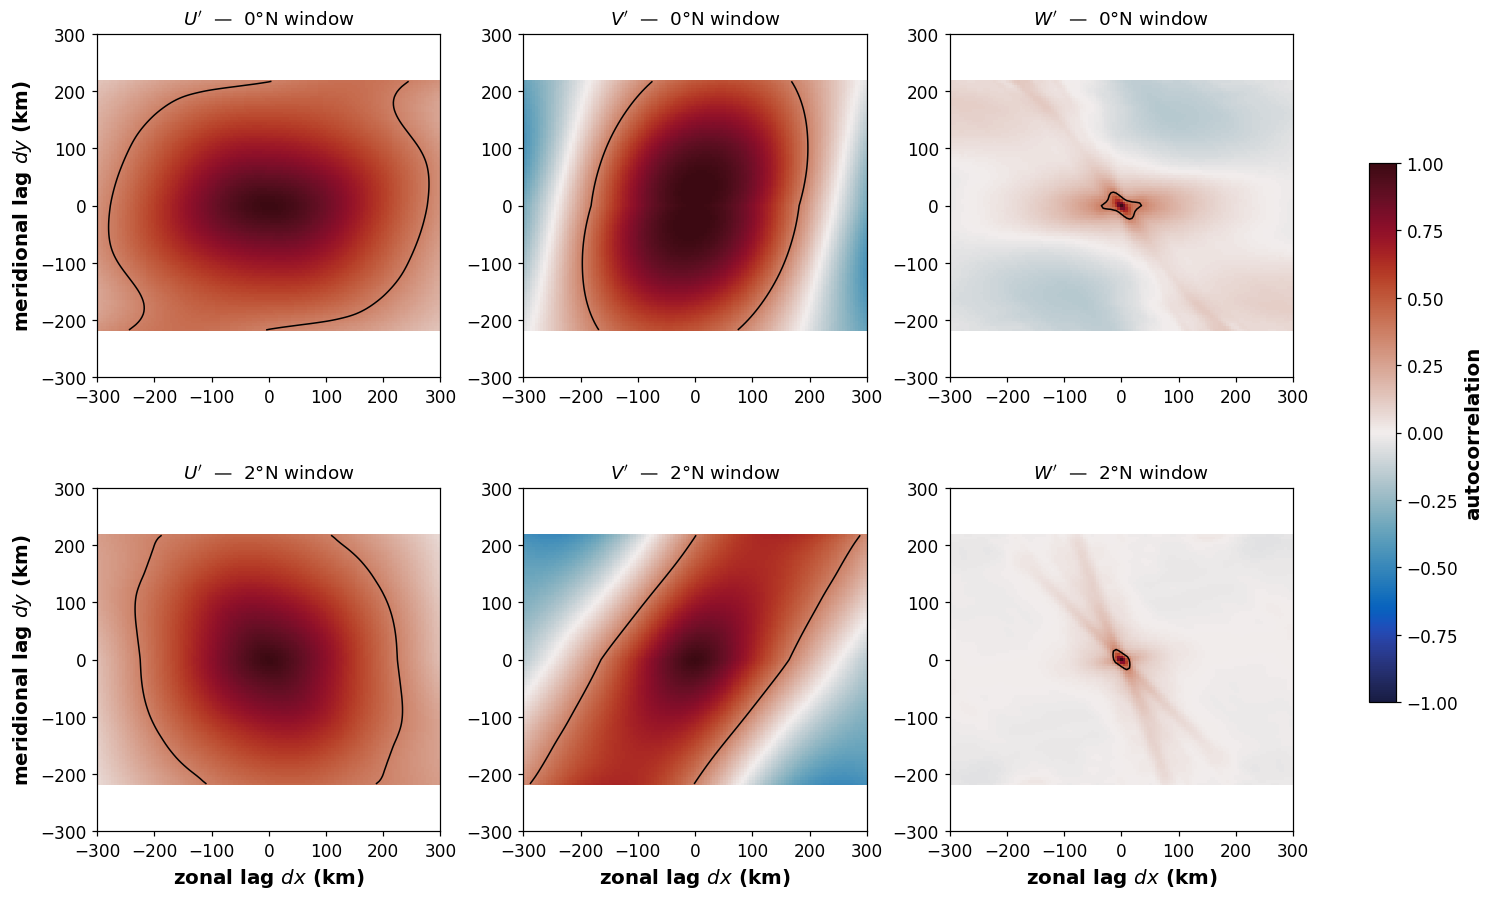

In [24]:
fig, ax = plt.subplots(2, 3, figsize=(13.5, 8.4), constrained_layout=True)
for i, lab in enumerate(wins):
    for j, f in enumerate(('U', 'V', 'W')):
        d = sc[f][lab]; C = d['C']
        ny = (C.shape[0]+1)//2; nx = (C.shape[1]+1)//2      # centre = zero lag
        LX = (np.arange(C.shape[1]) - (nx-1)) * dlon_km
        LY = (np.arange(C.shape[0]) - (ny-1)) * dlat_km
        a = ax[i, j]
        p = a.pcolormesh(LX, LY, C, cmap=cmo.balance, vmin=-1, vmax=1, shading='auto')
        a.contour(LX, LY, C, levels=[1/np.e], colors='k', linewidths=1)   # 1/e coherence
        a.set_xlim(-300, 300); a.set_ylim(-300, 300); a.set_aspect('equal')
        a.set_title(f"${f}'$  —  {lab} window")
        if i == 1:
            a.set_xlabel('zonal lag $dx$ (km)')
    ax[i, 0].set_ylabel('meridional lag $dy$ (km)')
fig.colorbar(p, ax=ax, shrink=0.6, label='autocorrelation')
fig.savefig(f'{FIGDIR}/fig10_uvw_lat_covmaps.png', bbox_inches='tight'); plt.show()

**Cuts** — rows $U',V',W'$; columns zonal / meridional / temporal; 0°N (blue) vs 2°N
(red). The dashed line on the $U,V$ meridional panels is the $\pm1°$ **window limit** — their
cuts never reach $1/e$ before running out of data, whereas $W$'s do:

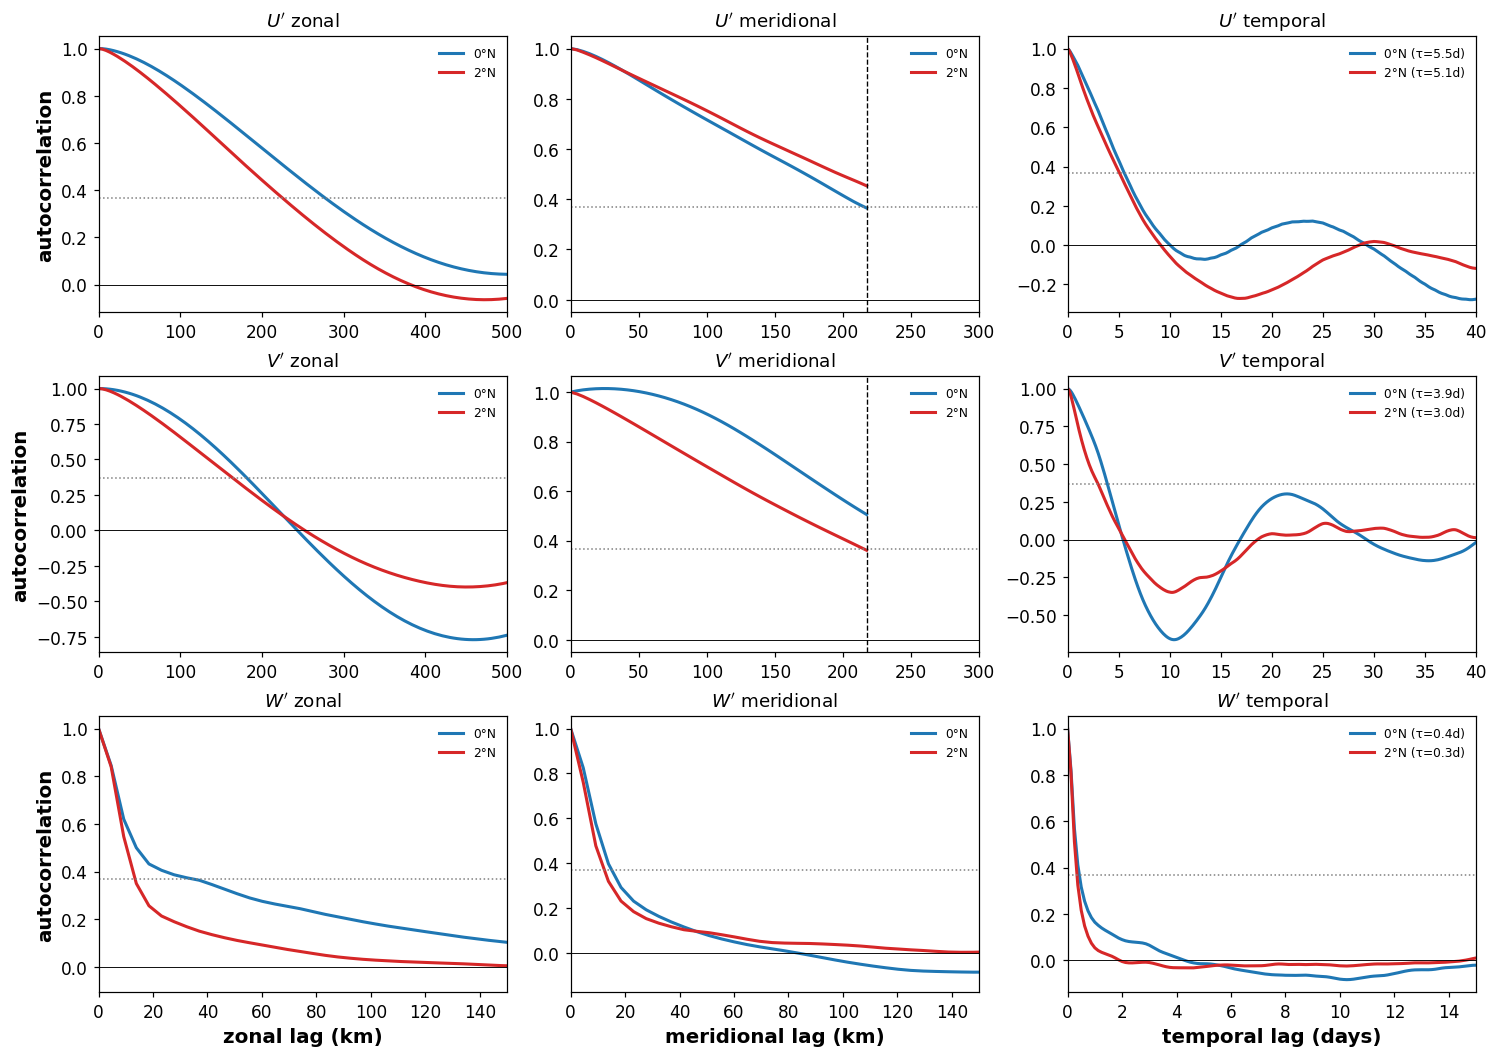

In [25]:
fig, ax = plt.subplots(3, 3, figsize=(13.5, 9.5), constrained_layout=True)
xl = {'U': (500, 300, 40), 'V': (500, 300, 40), 'W': (150, 150, 15)}   # per-field x-limits
for i, f in enumerate(('U', 'V', 'W')):
    for lab, col in [('0°N', 'C0'), ('2°N', 'C3')]:
        d = sc[f][lab]
        ax[i, 0].plot(d['lx'], d['Cx'], col, lw=2, label=lab)                 # zonal cut
        ax[i, 1].plot(d['ly'], d['Cy'], col, lw=2, label=lab)                 # meridional cut
        ax[i, 2].plot(lag_days, d['ac'], col, lw=2, label=f"{lab} (τ={d['tau']:.1f}d)")
    for j, (xl_j, ttl) in enumerate([(xl[f][0], f"${f}'$ zonal"),
                                     (xl[f][1], f"${f}'$ meridional"),
                                     (xl[f][2], f"${f}'$ temporal")]):
        a = ax[i, j]; a.axhline(0, color='k', lw=0.6)
        a.axhline(1/np.e, color='gray', ls=':', lw=1); a.set_xlim(0, xl_j); a.set_title(ttl)
        a.legend(loc='upper right', frameon=False, fontsize=8)
    if f in ('U', 'V'):
        ax[i, 1].axvline(win_km, color='k', ls='--', lw=0.9)                  # window limit
    ax[i, 0].set_ylabel('autocorrelation')
for j, xlab in enumerate(['zonal lag (km)', 'meridional lag (km)', 'temporal lag (days)']):
    ax[2, j].set_xlabel(xlab)
fig.savefig(f'{FIGDIR}/fig11_uvw_lat_cuts.png', bbox_inches='tight'); plt.show()

**Result — scales change with latitude, and the window size matters differently by
direction:**

- **Zonal (localisable for all fields):** the zonal scale shrinks equator → 2°N for every
  component — $U$ 277 → 225 km, $V$ 182 → 164 km, $W$ 35 → 13 km ($1/e$). $W$ changes most
  and is zonally elongated on the equator, near-isotropic by 2°N.
- **Meridional (localisable only for $W$):** $W$'s meridional scale (~12–15 km) sits well
  inside the $\pm1°$ window; $U,V$'s (~200–280 km) does **not**, so their meridional cut never
  reaches $1/e$ — "unresolved / >window" in the table. Measuring $U,V$ meridionally *requires*
  the wide $-5…5°$ window, but that window is itself ~as tall as the scale and spans several
  latitude regimes: $U,V$'s meridional decorrelation is inherently **non-local** near the
  equator (you cannot have both locality and meridional resolution).
- **Temporal:** mild decrease off-equator ($U$ 5.5 → 5.1 d, $V$ 3.9 → 3.0 d, $W$ 0.4 → 0.3 d).

So the wide-window numbers reported earlier are the right ones **meridionally** for $U,V$ (a
narrow window can't measure them), while a narrow, latitude-specific window is needed to see
how the **zonal** scales — and all of $W$ — vary across the equator.

## Summary

For the near-surface (25 m) velocity over the equatorial 140°W footprint:

* The **anomaly** autocovariance (Step 2b) is the estimate that feeds the plane-fit
  sampling error — far better sampled and more stable than the single-realisation
  mean-map estimate (Step 2a).
* The field is **anisotropic and oscillatory**: report both the **e-folding** (coherence)
  and **first-zero-crossing** (TIW half-wavelength) scales — a pure exponential captures
  only the coherent core. Samples a half-wavelength apart are anti-correlated, *not*
  independent.
* Error bars on $L$ are set by the **temporal** decorrelation time (τ ≈ 1 week →
  ~13 independent realisations in 3 months), giving ~±25–30% uncertainty on each fitted
  $L$. The short record genuinely undersamples the low-frequency mean.
* The **vertical velocity $W$** (supplementary — it does not feed the plane-fit error, but
  it is the upwelling being estimated) has a mean map dominated by the narrow equatorial
  upwelling core and decorrelates over markedly *shorter* spatial and temporal scales than
  $U,V$; the $W$ table and figures above give its $L_x,L_y$, zero crossings and $\tau_W$.

The printed numbers above (fitted $L_x$, $L_y$, zero crossings, τ, $N_\mathrm{eff}$, and
the $W$ scales) are the quantities the AUV-array sampling-error analysis needs.